# Selekcija instanci u mašinskom učenju - Praktičan deo

**Univerzitet u Nišu - Elektronski fakultet**

**Studijski program:** Veštačka inteligencija i mašinsko učenje
**Predmet:** Prikupljanje i predobrada podataka za mašinsko učenje
**Mentor:** prof. dr Aleksandar Stanimirović
**Student:** Aleksa Cekić, br. ind. 2117

---

## O praktičnom delu

Cilj ovog notebook-a je da na konkretnom primeru demonstrira metode selekcije instanci obrađene u teorijskom delu rada. Korišćen je **Wine Quality (Red)** dataset iz UCI repozitorijuma koji sadrži 1599 instanci crvenog vina opisanih sa 11 fizičko-hemijskih atributa (kiselost, šećer, hloridi, pH, alkohol itd.), dok je ciljna promenljiva ocena kvaliteta vina.

Kao klasifikator korišćen je **k-Nearest Neighbors (k-NN)** jer je to algoritam koji direktno zavisi od svih instanci u trening skupu. Svaka predikcija zahteva računanje rastojanja do svih trening primera. To ga čini idealnim za demonstraciju selekcije instanci: smanjenje broja instanci direktno ubrzava k-NN, a uklanjanje šumnih instanci direktno poboljšava kvalitet njegovih predikcija.

Najpre se uspostavljaju baseline rezultati k-NN-a na kompletnom trening skupu, a zatim se primenjuju metode selekcije instanci i porede rezultati sa baseline-om.

## Učitavanje i osnovna analiza skupa podataka
Prvo je potrebno učitati podatke iz dataset-a Wine Quality i izvršiti osnovnu analizu strukture podataka, tipovi atributa i ukupnog broja instanci.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

import time

from imblearn.under_sampling import (
    EditedNearestNeighbours,
    RepeatedEditedNearestNeighbours,
    AllKNN,
    CondensedNearestNeighbour,
    TomekLinks
)

import warnings
warnings.filterwarnings('ignore')

In [105]:
df = pd.read_csv('data/winequality-red.csv')

print("Dimenzije skupa podataka: ", df.shape)
df.head()

Dimenzije skupa podataka:  (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dimenzije skupa podataka
Proveravamo tipove podataka i nedostajuće vrednosti. Tipovi su bitni jer k-NN zahteva numeričke atribute, a nedostajuće vrednosti bi morale da se imputuju pre primene bilo kog algoritma zasnovanog na rastojanju.

In [106]:
print(f"Tipovi podataka:")
print(df.dtypes)
print(f"\nNedostajuće vrednosti po atributu:")
print(df.isnull().sum())
print(f"\nUkupno nedostajućih vrednosti: {df.isnull().sum().sum()}")

Tipovi podataka:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Nedostajuće vrednosti po atributu:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Ukupno nedostajućih vrednosti: 0


## Osnovna statistika numeričkih atributa
Prikaz osnovnih statističkih mera (srednja vrednost, standardna devijacija, minimum, maksimum i kvartili) daje uvid u raspodelu atributa i njihove opsege vrednosti, što je bitno jer k-NN koristi Euklidsko rastojanje i atributi sa većim opsegom bi dominirali nad ostalima.

In [107]:
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


## Distribucija ciljne promenljive
Analiza distribucije klasa je ključna za selekciju instanci. Nebalansiranost klasa direktno utiče na k-NN jer ako većina instanci pripada jednoj klasi, većina najbližih suseda će uvek biti iz te klase, što dovodi do pristrasne klasifikacije.

Distribucija klasa (quality):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Procentualna zastupljenost:
quality
3     0.6
4     3.3
5    42.6
6    39.9
7    12.4
8     1.1
Name: proportion, dtype: float64


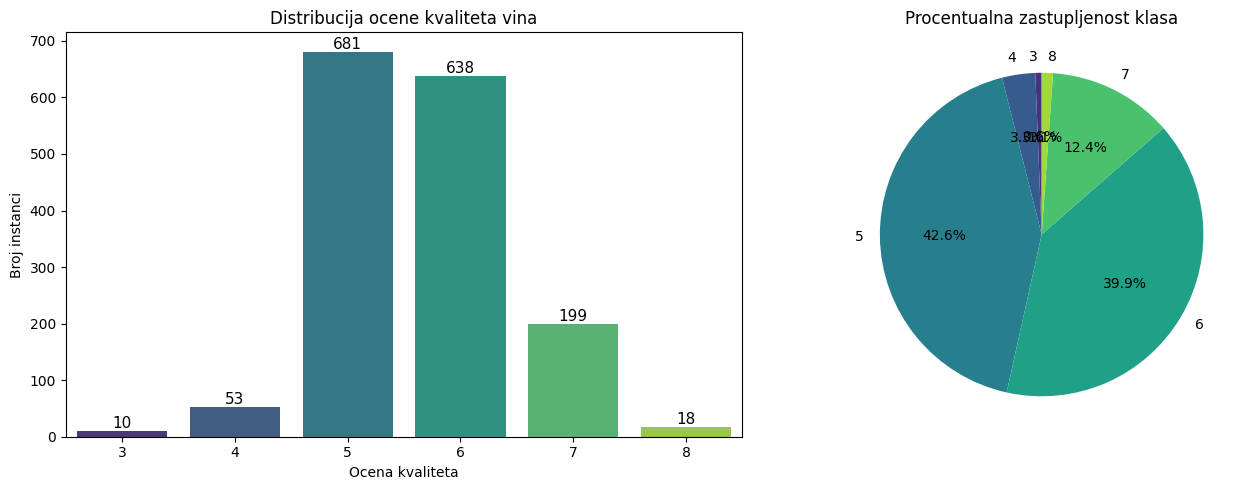

In [108]:
print("Distribucija klasa (quality):")
print(df['quality'].value_counts().sort_index())
print(f"\nProcentualna zastupljenost:")
print((df['quality'].value_counts(normalize=True).sort_index() * 100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='quality', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribucija ocene kvaliteta vina')
axes[0].set_xlabel('Ocena kvaliteta')
axes[0].set_ylabel('Broj instanci')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
axes[1].pie(df['quality'].value_counts().sort_index(),
            labels=df['quality'].value_counts().sort_index().index,
            autopct='%1.1f%%',
            colors=sns.color_palette('viridis', 6),
            startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa')

plt.tight_layout()
plt.show()

Distribucija pokazuje izrazitu nebalansiranost klasa. Klase 5 i 6 zajedno čine oko 82.5% svih instanci (681 + 638 = 1319), dok klase 3 i 8 imaju samo 10 i 18 primeraka. Ovo je klasičan primer nebalansiranosti koji direktno utiče na k-NN klasifikator. Većina najbližih suseda nove instance će gotovo uvek pripadati klasama 5 ili 6, što znači da će retke klase biti sistematski pogrešno klasifikovane.

Sa 6 klasa od kojih neke imaju manje od 20 instanci, klasifikacija bi bila nepouzdana. Zbog toga ćemo grupisati ocene u tri kategorije: loš kvalitet (3-5), srednji kvalitet (6) i dobar kvalitet (7-8), čime dobijamo manji broj klasa sa dovoljnim brojem instanci u svakoj za smislenu primenu selekcije instanci.

## Grupisanje klasa
Pošto originalni dataset ima 6 klasa od kojih neke imaju manje od 20 instanci, grupišemo ocene u tri kategorije kako bismo dobili dovoljno primeraka u svakoj klasi za pouzdanu klasifikaciju i smislenu primenu metoda selekcije instanci.

Distribucija grupisanih klasa:
quality_class
0    744
1    638
2    217
Name: count, dtype: int64

Procentualna zastupljenost:
quality_class
0    46.5
1    39.9
2    13.6
Name: proportion, dtype: float64


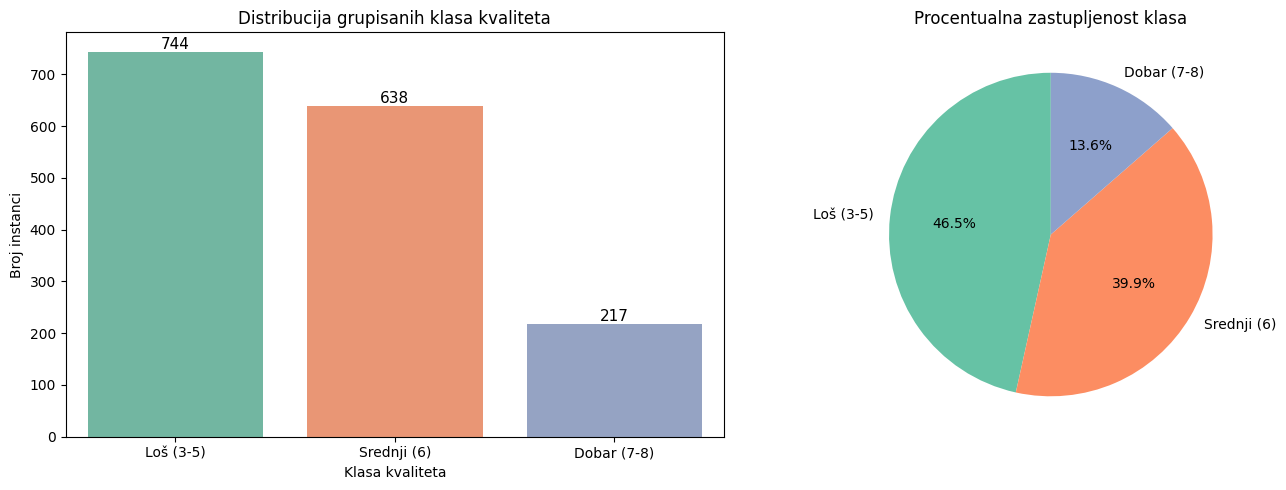

In [109]:
def map_quality(q):
    if q <= 5:
        return 0  # Loš kvalitet
    elif q == 6:
        return 1  # Srednji kvalitet
    else:
        return 2  # Dobar kvalitet

df['quality_class'] = df['quality'].apply(map_quality)

print("Distribucija grupisanih klasa:")
print(df['quality_class'].value_counts().sort_index())
print(f"\nProcentualna zastupljenost:")
print((df['quality_class'].value_counts(normalize=True).sort_index() * 100).round(1))

labels = ['Loš (3-5)', 'Srednji (6)', 'Dobar (7-8)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.countplot(x='quality_class', data=df, palette='Set2', ax=axes[0])
ax.set_xticklabels(labels)
axes[0].set_title('Distribucija grupisanih klasa kvaliteta')
axes[0].set_xlabel('Klasa kvaliteta')
axes[0].set_ylabel('Broj instanci')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

axes[1].pie(df['quality_class'].value_counts().sort_index(), 
            labels=labels,
            autopct='%1.1f%%', 
            colors=sns.color_palette('Set2', 3),
            startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa')

plt.tight_layout()
plt.show()

Nakon grupisanja imamo tri klase: loš kvalitet sa 744 instance (46.5%), srednji sa 638 (39.9%) i dobar sa 217 (13.6%). Klase su i dalje nebalansirane. Klasa 2 (dobar kvalitet) ima skoro 3.5 puta manje instanci od klase 0, što znaci da će k-NN i dalje težiti da favorizuje klase 0 i 1. Međutim, sada svaka klasa ima dovoljno instanci za pouzdanu klasifikaciju i evaluaciju metoda selekcije instanci.

## Distribucije atributa
Vizualizacija distribucija svih numeričkih atributa pomaže da se identifikuju outlieri i asimetrične distribucije. Ovo je relevantno za selekciju instanci jer outlieri i instance sa ekstremnim vrednostima su upravo one koje edition metode poput ENN ciljaju za uklanjanje.

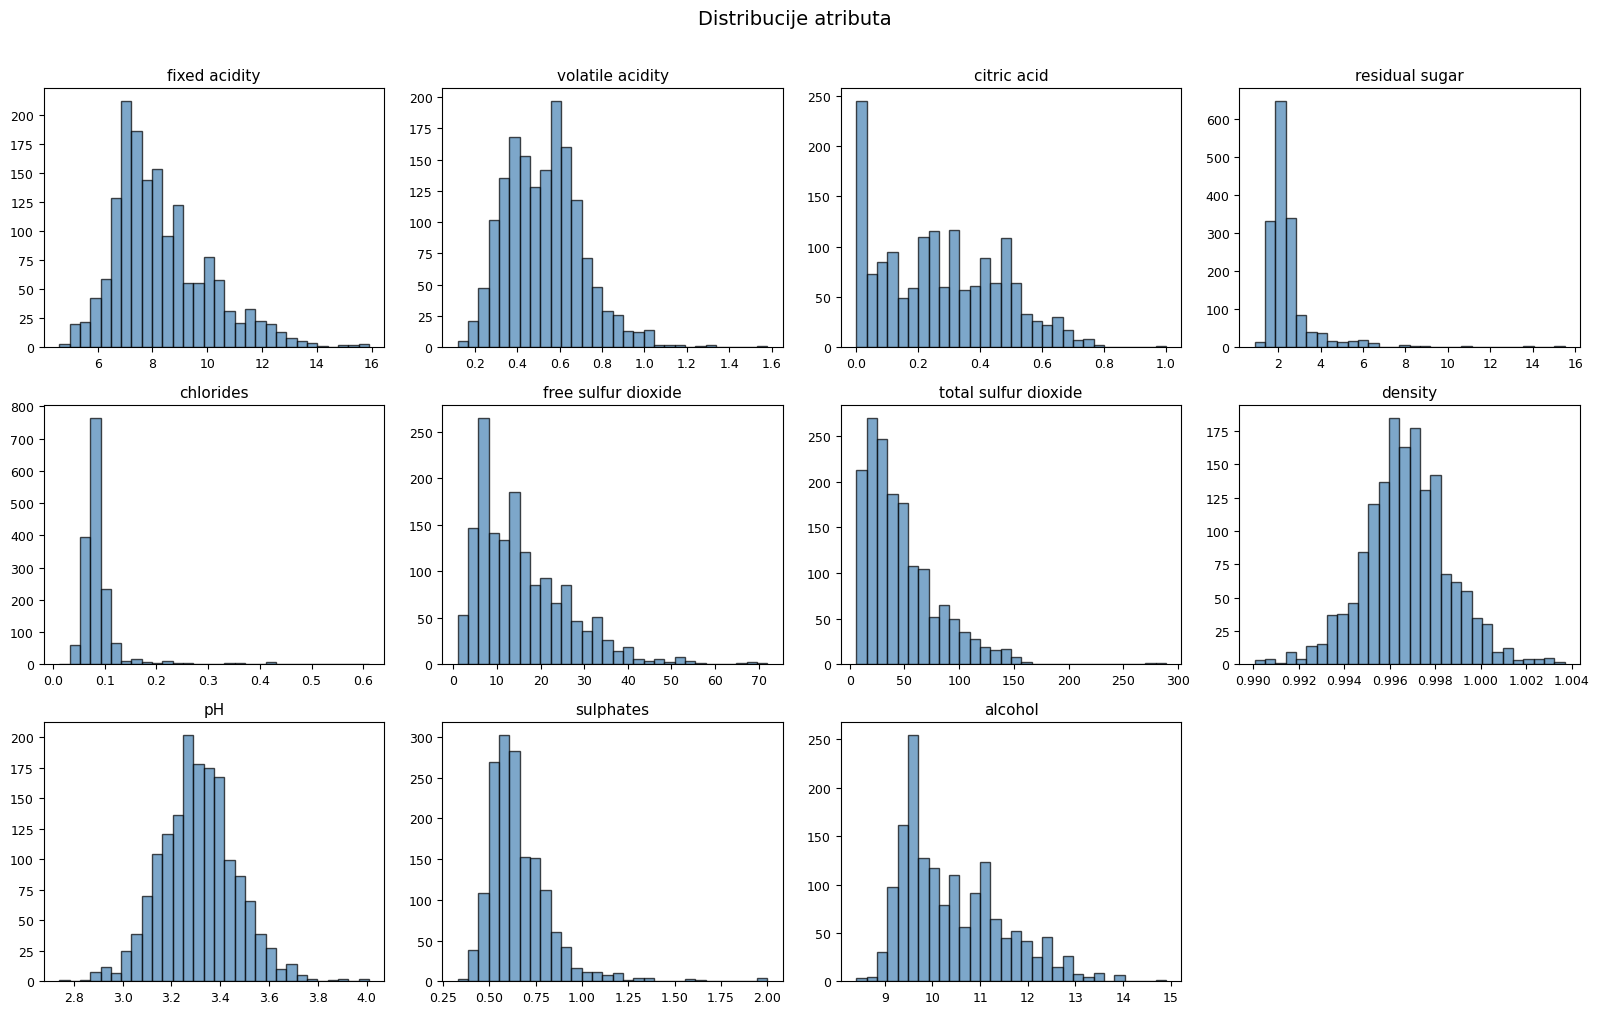

In [110]:
features = df.columns[:-2]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(labelsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribucije atributa', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Većina atributa ima asimetricnu distribuciju sa desnim repom, posebno `residual sugar`, `chlorides`, `sulphates` i `total sulfur dioxide`. Dugi repovi ukazuju na prisustvo outliera, instanci sa ekstremnim vrednostima koje se nalaze daleko od centra distribucije. Atributi `pH` i `density` imaju približno normalnu distribuciju. Ovi outlieri su potencijalni kandidati za uklanjanje edition metodama jer se često nalaze u blizini instanci druge klase i mogu negativno uticati na k-NN klasifikaciju.

## Korelaciona matrica
Analiza korelacija između atributa pomaže da se razume struktura podataka i identifikuju potencijalno redundantni atributi koji ne doprinose dodatnim informacijama za klasifikaciju.

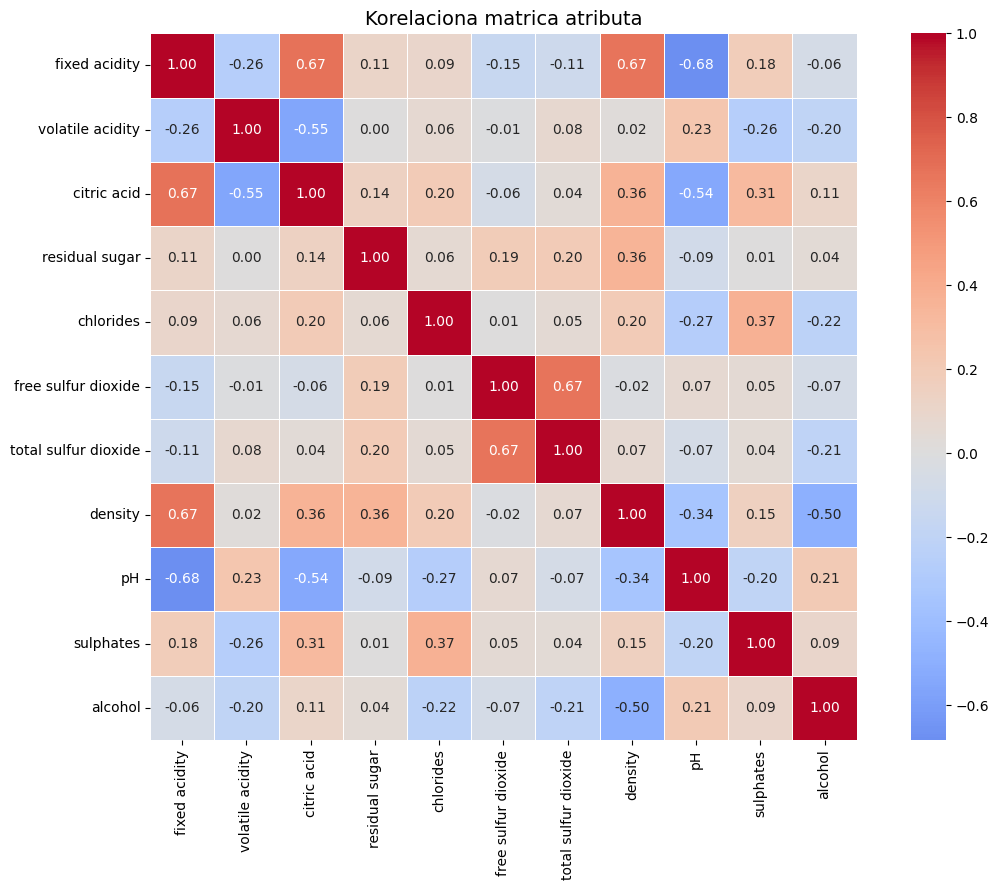

In [111]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Korelaciona matrica atributa', fontsize=14)
plt.tight_layout()
plt.show()

## Box plotovi po klasama
Box plotovi pokazuju kako se distribucije atributa razlikuju između klasa kvaliteta. Atributi sa jasnom razlikom između klasa su najinformativniji za klasifikaciju, dok oni sa velikim preklapanjem stvaraju granične oblasti gde k-NN pravi greške i gde selekcija instanci moze da pomogne.

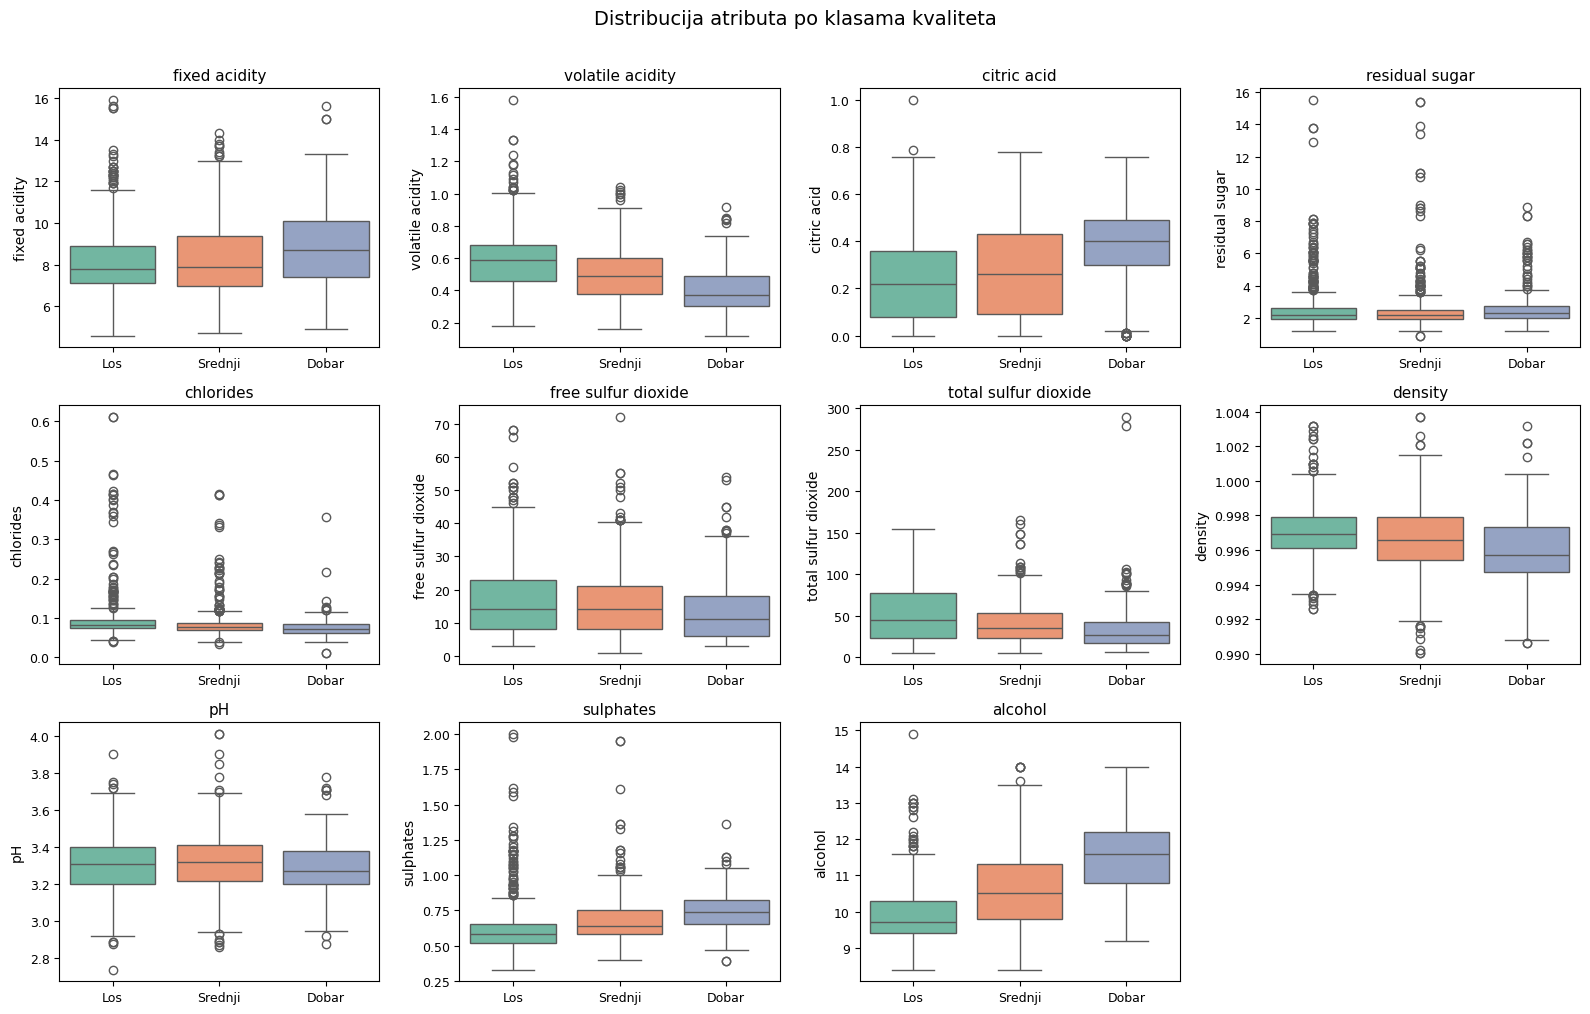

In [112]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
labels = ['Los', 'Srednji', 'Dobar']

for i, col in enumerate(features):
    sns.boxplot(x='quality_class', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(labels)
    axes[i].tick_params(labelsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribucija atributa po klasama kvaliteta', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Iz box plotova se vidi da `alcohol` i `volatile acidity` imaju najjasniju razliku između klasa, dok atributi poput `residual sugar` i `pH` imaju veliko preklapanje. Takođe, većina atributa sadrži outliere koji su potencijalni kandidati za uklanjanje edition metodama.

## Priprema podataka za klasifikaciju
Odvajamo atribute od ciljne promenljive, delimo podatke na trening (70%) i test (30%) skup, i standardizujemo atribute. Standardizacija je neophodna jer k-NN koristi Euklidsko rastojanje, bez nje bi atributi sa većim opsegom dominirali. Bitno je da se fit_transform radi samo na trening skupu, a na test skupu samo transform, kako informacije iz test skupa ne bi uticale na treniranje (data leakage).

In [113]:
X = df[features]
y = df['quality_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Trening skup: {X_train_scaled.shape[0]} instanci")
print(f"Test skup: {X_test_scaled.shape[0]} instanci")
print(f"\nDistribucija klasa u trening skupu:")
print(y_train.value_counts().sort_index())
print(f"\nDistribucija klasa u test skupu:")
print(y_test.value_counts().sort_index())

Trening skup: 1119 instanci
Test skup: 480 instanci

Distribucija klasa u trening skupu:
quality_class
0    521
1    446
2    152
Name: count, dtype: int64

Distribucija klasa u test skupu:
quality_class
0    223
1    192
2     65
Name: count, dtype: int64


## Baseline k-NN klasifikacija
Pre primene bilo koje metode selekcije instanci, potrebno je uspostaviti baseline rezultate. Performanse k-NN klasifikatora treniranog na kompletnom trening skupu bez ikakvih modifikacija. Ovi rezultati služe kao referentna tačka sa kojom ćemo porediti rezultate nakon primene selekcije instanci. Merimo i vreme treniranja i predikcije jer je jedan od glavnih ciljeva selekcije instanci upravo ubrzanje.

In [114]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

start_time = time.time()
knn.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred = knn.predict(X_test_scaled)
predict_time = time.time() - start_time

print(f"Baseline k-NN (k={k})")
print(f"Broj instanci u trening skupu: {X_train_scaled.shape[0]}")
print(f"Vreme treniranja: {train_time:.4f}s")
print(f"Vreme predikcije: {predict_time:.4f}s")
print(f"\nTačnost: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred, target_names=['Los', 'Srednji', 'Dobar']))

Baseline k-NN (k=5)
Broj instanci u trening skupu: 1119
Vreme treniranja: 0.0014s
Vreme predikcije: 0.0062s

Tačnost: 0.6438

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Los       0.73      0.70      0.72       223
     Srednji       0.58      0.61      0.60       192
       Dobar       0.56      0.52      0.54        65

    accuracy                           0.64       480
   macro avg       0.62      0.61      0.62       480
weighted avg       0.65      0.64      0.64       480



## Confusion matrica (Baseline)
Confusion matrica prikazuje koliko je instanci iz svake klase pravilno i pogrešno klasifikovano, što omogućava da se identifikuju problematični parovi klasa gde dolazi do najvećeg mešanja.

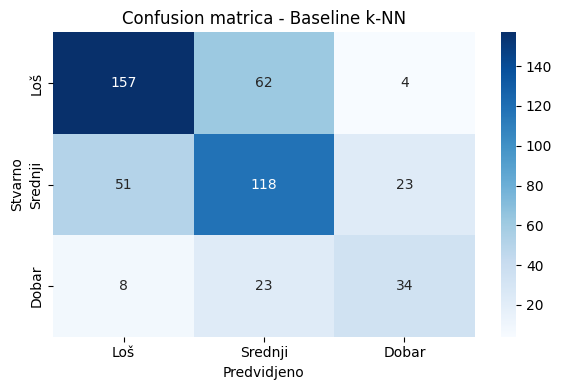

In [115]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loš', 'Srednji', 'Dobar'],
            yticklabels=['Loš', 'Srednji', 'Dobar'])
plt.title('Confusion matrica - Baseline k-NN')
plt.xlabel('Predvidjeno')
plt.ylabel('Stvarno')
plt.tight_layout()
plt.show()

Najveće mešanje je izmedju klasa Loš i Srednji, 62 instance klase Loš su pogrešno klasifikovane kao Srednji, i 51 instanca klase Srednji kao Loš. Ovo ukazuje na veliko preklapanje između ove dve klase u feature space-u, što znači da se u tim oblastima nalaze šumne i granične instance koje zbunjuju k-NN klasifikator. Selekcija instanci može da pomogne ovde. Edition metode uklanjanjem šumnih instanci sa granice, a kondenzacija zadržavanjem samo kritičnih boundary instanci.

## Primena metoda selekcije instanci
U ovom delu primenjujemo metode selekcije instanci koje su obrađene u teorijskom delu rada. Koristimo biblioteku imbalanced-learn koja implementira ove metode. Svaku metodu primenjujemo na trening skup, zatim treniramo k-NN na redukovanom skupu i poredimo rezultate sa baseline-om. Za svaku metodu pratimo tačnost, F1-score, stopu redukcije i vreme predikcije.

In [116]:
results = []

results.append({
    'Method': 'Baseline (without selection)',
    'Num of instances': X_train_scaled.shape[0],
    'Reduction (%)': 0.0,
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    'Predict time (s)': predict_time
})

print(f"Vreme predvidjanja: {predict_time}")
print(f"Baseline sačuvan: {X_train_scaled.shape[0]} instanci, tačnost: {accuracy_score(y_test, y_pred):.4f}")

Vreme predvidjanja: 0.006201744079589844
Baseline sačuvan: 1119 instanci, tačnost: 0.6438


## Edited Nearest Neighbours (ENN)
ENN je edition metoda koja uklanja instance čiji se najbliži susedi većinski nalaze u drugoj klasi. Takve instance su verovatno šumne ili pogrešno označene. ENN ne cilja drastičnu redukciju već poboljšanje kvaliteta podataka. Očekujemo umerenu redukciju (10-30%) sa potencijalnim poboljšanjem tačnosti.

In [117]:
enn = EditedNearestNeighbours(n_neighbors=3)
X_enn, y_enn = enn.fit_resample(X_train_scaled, y_train)

knn_enn = KNeighborsClassifier(n_neighbors=k)
knn_enn.fit(X_enn, y_enn)

start_time = time.time()
y_pred_enn = knn_enn.predict(X_test_scaled)
predict_time_enn = time.time() - start_time

reduction = (1 - len(X_enn) / len(X_train_scaled)) * 100
acc_enn = accuracy_score(y_test, y_pred_enn)

results.append({
    'Method': 'ENN',
    'Num of instances': len(X_enn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_enn,
    'F1 (weighted)': f1_score(y_test, y_pred_enn, average='weighted'),
    'Predict time (s)': predict_time_enn
})

print(f"ENN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_enn)} (redukcija: {reduction:.1f}%)")
print(f"Tačnost: {acc_enn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_enn, target_names=['Loš', 'Srednji', 'Dobar']))

ENN rezultati:
Broj instanci: 1119 -> 447 (redukcija: 60.1%)
Tačnost: 0.5583 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Loš       0.72      0.68      0.70       223
     Srednji       0.55      0.34      0.42       192
       Dobar       0.35      0.80      0.48        65

    accuracy                           0.56       480
   macro avg       0.54      0.61      0.53       480
weighted avg       0.60      0.56      0.56       480



ENN je uklonio 60.1% instanci, što je znatno više od tipičnih 10-30%. Ovo ukazuje na veliko preklapanje između klasa u feature space-u. Tačnost je pala sa 0.64 na 0.56 jer je ENN bio preagresivan, uklonio je i validne granicne instance, posebno iz klase Srednji čiji je recall pao sa 0.61 na 0.34.

## Repeated Edited Nearest Neighbours (RENN)
RENN iterativno primenjuje ENN dok god se uklanjaju instance. Ovo omogućava uklanjanje klastera šumnih instanci koje običan ENN ne detektuje u jednom prolazu jer se međusobno podržavaju. Očekujemo veću redukciju od ENN-a ali sa rizikom dodatnog pada tačnosti.

In [118]:
renn = RepeatedEditedNearestNeighbours(n_neighbors=3)
X_renn, y_renn = renn.fit_resample(X_train_scaled, y_train)

knn_renn = KNeighborsClassifier(n_neighbors=k)
knn_renn.fit(X_renn, y_renn)

start_time = time.time()
y_pred_renn = knn_renn.predict(X_test_scaled)
predict_time_renn = time.time() - start_time

reduction = (1 - len(X_renn) / len(X_train_scaled)) * 100
acc_renn = accuracy_score(y_test, y_pred_renn)

results.append({
    'Method': 'RENN',
    'Num of instances': len(X_renn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_renn,
    'F1 (weighted)': f1_score(y_test, y_pred_renn, average='weighted'),
    'Predict time (s)': predict_time_renn
})

print(f"RENN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_renn)} (redukcija: {reduction:.1f}%)")
print(f"Tačnost: {acc_renn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_renn, target_names=['Loš', 'Srednji', 'Dobar']))

RENN rezultati:
Broj instanci: 1119 -> 447 (redukcija: 60.1%)
Tačnost: 0.5583 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Loš       0.72      0.68      0.70       223
     Srednji       0.55      0.34      0.42       192
       Dobar       0.35      0.80      0.48        65

    accuracy                           0.56       480
   macro avg       0.54      0.61      0.53       480
weighted avg       0.60      0.56      0.56       480



RENN je dao identičan rezultat kao ENN: istih 447 instanci, ista tačnost 0.5583. Ovo ukazuje na to da je ENN u prvom prolazu već uklonio sve instance koje RENN bi mogao da detektuje. Nakon prvog prolaza nije ostao nijedan klaster šumnih instanci koji bi se otkrio u sledećim iteracijama. RENN je konvergirao u jednoj iteraciji.

## AllKNN
AllKNN je konzervativnija varijanta ENN-a koja primenjuje ENN sa više različitih vrednosti k (od 1 do n_neighbors). Instanca se uklanja samo ako je pogrešno klasifikovana za sve testirane vrednosti k, što znači da mora postojati jak signal da je instanca problematična. Očekujemo manju redukciju ali potencijalno bolje očuvanje tačnosti jer se ne uklanjaju validne granicne instance.

In [119]:
allknn = AllKNN(n_neighbors=3)
X_allknn, y_allknn = allknn.fit_resample(X_train_scaled, y_train)

knn_allknn = KNeighborsClassifier(n_neighbors=k)
knn_allknn.fit(X_allknn, y_allknn)

start_time = time.time()
y_pred_allknn = knn_allknn.predict(X_test_scaled)
predict_time_allknn = time.time() - start_time

reduction = (1 - len(X_allknn) / len(X_train_scaled)) * 100
acc_allknn = accuracy_score(y_test, y_pred_allknn)

results.append({
    'Method': 'AllKNN',
    'Num of instances': len(X_allknn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_allknn,
    'F1 (weighted)': f1_score(y_test, y_pred_allknn, average='weighted'),
    'Predict time (s)': predict_time_allknn
})

print(f"AllKNN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_allknn)} (redukcija: {reduction:.1f}%)")
print(f"Tačnost: {acc_allknn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_allknn, target_names=['Loš', 'Srednji', 'Dobar']))

AllKNN rezultati:
Broj instanci: 1119 -> 474 (redukcija: 57.6%)
Tačnost: 0.5750 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Loš       0.73      0.68      0.70       223
     Srednji       0.57      0.36      0.44       192
       Dobar       0.37      0.86      0.52        65

    accuracy                           0.57       480
   macro avg       0.56      0.63      0.55       480
weighted avg       0.62      0.57      0.57       480



AllKNN je ocuvao 27 instanci više od ENN-a zahvaljujući konzervativnijem pristupu, uz blago bolju tačnost (0.575 vs 0.558). Ipak, tačnost je i dalje ispod baseline-a, što potvrdjuje da je preklapanje izmedju klasa u ovom datasetu previše izraženo da bi edition metode same mogle da ga reše.

## Condensed Nearest Neighbour (CNN)
CNN je metoda kondenzacije koja zadržava samo instance neophodne za pravilnu klasifikaciju. Uglavnom granicne instance između klasa. Za razliku od edition metoda koje ciljaju kvalitet podataka, CNN cilja maksimalnu redukciju veličine. Očekujemo drastičnu redukciju (70-95%) ali sa mogućim padom tačnosti jer CNN ne uklanja šum već može i da ga zadrži.

In [120]:
cnn = CondensedNearestNeighbour(random_state=42)
X_cnn, y_cnn = cnn.fit_resample(X_train_scaled, y_train)

knn_cnn = KNeighborsClassifier(n_neighbors=k)
knn_cnn.fit(X_cnn, y_cnn)

start_time = time.time()
y_pred_cnn = knn_cnn.predict(X_test_scaled)
predict_time_cnn = time.time() - start_time

reduction = (1 - len(X_cnn) / len(X_train_scaled)) * 100
acc_cnn = accuracy_score(y_test, y_pred_cnn)

results.append({
    'Method': 'CNN',
    'Num of instances': len(X_cnn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_cnn,
    'F1 (weighted)': f1_score(y_test, y_pred_cnn, average='weighted'),
    'Predict time (s)': predict_time_cnn
})

print(f"CNN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_cnn)} (redukcija: {reduction:.1f}%)")
print(f"Tačnost: {acc_cnn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_cnn, target_names=['Loš', 'Srednji', 'Dobar']))

CNN rezultati:
Broj instanci: 1119 -> 432 (redukcija: 61.4%)
Tačnost: 0.5500 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Loš       0.67      0.64      0.66       223
     Srednji       0.48      0.43      0.45       192
       Dobar       0.40      0.58      0.48        65

    accuracy                           0.55       480
   macro avg       0.52      0.55      0.53       480
weighted avg       0.56      0.55      0.55       480



CNN je postigao redukciju od 61.4% ali i najnižu tačnost među ne-hibridnim metodama (0.55). CNN zadržava granicne instance ali ne razlikuje validne od šumnih, što degradira klasifikaciju. Ovo motiviše hibridne metode poput DROP3 koje prvo čiste šum pa onda kondenzuju.

## Tomek Links
Tomek Links identifikuje parove najbližih suseda koji pripadaju različitim klasama i uklanja instancu iz većinske klase. Ovo metoda cilja samo najočiglednije granicne konflikte i postiže najmanju redukciju, ali sa minimalnim rizikom od gubitka korisnih instanci.

In [121]:
tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_train_scaled, y_train)

knn_tomek = KNeighborsClassifier(n_neighbors=k)
knn_tomek.fit(X_tomek, y_tomek)

start_time = time.time()
y_pred_tomek = knn_tomek.predict(X_test_scaled)
predict_time_tomek = time.time() - start_time

reduction = (1 - len(X_tomek) / len(X_train_scaled)) * 100
acc_tomek = accuracy_score(y_test, y_pred_tomek)

results.append({
    'Method': 'Tomek Links',
    'Num of instances': len(X_tomek),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_tomek,
    'F1 (weighted)': f1_score(y_test, y_pred_tomek, average='weighted'),
    'Predict time (s)': predict_time_tomek
})

print(f"Tomek Links rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_tomek)} (redukcija: {reduction:.1f}%)")
print(f"Tačnost: {acc_tomek:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_tomek, target_names=['Loš', 'Srednji', 'Dobar']))

Tomek Links rezultati:
Broj instanci: 1119 -> 986 (redukcija: 11.9%)
Tačnost: 0.6375 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Loš       0.73      0.72      0.72       223
     Srednji       0.58      0.56      0.57       192
       Dobar       0.51      0.58      0.55        65

    accuracy                           0.64       480
   macro avg       0.61      0.62      0.61       480
weighted avg       0.64      0.64      0.64       480



Tomek Links je uklonio samo 11.9% instanci ali sačuvao tačnost skoro identičnu baseline-u (0.6375 vs 0.6438). Ovo je najmanji pad tačnosti od svih metoda, što potvrdjuje da konzervativniji pristup bolje čuva kvalitet klasifikacije na ovom datasetu.

## DROP3 (Decremental Reduction Optimization Procedure 3)
DROP3 je hibridna metoda koja kombinuje edition i kondenzaciju u dva koraka: prvo primenjuje ENN za čiscenje šuma, zatim decrementalno uklanja instance čiji associates ostaju pravilno klasifikovani i bez njih. Ne postoji gotova Python biblioteka koja implementira DROP3, pa je algoritam implementiran ručno prema originalnom radu Wilson & Martinez (2000).

In [122]:
def drop3(X, y, k=5):
    # Faza 1: ENN čiscenje šuma
    enn = EditedNearestNeighbours(n_neighbors=3)
    X_clean, y_clean = enn.fit_resample(X, y)
    print(f"Posle ENN faze: {len(X)} -> {len(X_clean)} instanci")
    
    X_s = np.array(X_clean)
    y_s = np.array(y_clean)
    n = len(X_s)
    
    enemy_dist = np.zeros(n)
    for i in range(n):
        mask = y_s != y_s[i]
        if mask.sum() > 0:
            dists = np.linalg.norm(X_s[mask] - X_s[i], axis=1)
            enemy_dist[i] = np.min(dists)
    
    order = np.argsort(enemy_dist)[::-1]
    keep = np.ones(n, dtype=bool)
    
    for idx in order:
        if not keep[idx]:
            continue
        
        active_idx = np.where(keep)[0]
        if len(active_idx) <= k + 1:
            break
        
        X_active = X_s[keep]
        y_active = y_s[keep]
        pos = np.where(active_idx == idx)[0][0]
        
        nn = NearestNeighbors(n_neighbors=min(k + 1, len(X_active)))
        nn.fit(X_active)
        distances, indices = nn.kneighbors(X_active)
        
        associates = []
        for i in range(len(X_active)):
            if i == pos:
                continue
            if pos in indices[i][1:]:
                associates.append(i)
        
        if len(associates) == 0:
            continue
        
        correct_with = 0
        for a in associates:
            neighbor_labels = y_active[indices[a][1:]]
            if len(neighbor_labels) > 0:
                pred = np.bincount(neighbor_labels.astype(int)).argmax()
                if pred == y_active[a]:
                    correct_with += 1
        
        if correct_with == 0:
            continue
        
        keep_without = keep.copy()
        keep_without[idx] = False
        X_without = X_s[keep_without]
        y_without = y_s[keep_without]
        
        if len(X_without) <= k:
            continue
        
        nn2 = NearestNeighbors(n_neighbors=min(k, len(X_without)))
        nn2.fit(X_without)
        
        correct_without = 0
        for a in associates:
            orig_idx = active_idx[a]
            if keep_without[orig_idx]:
                point = X_s[orig_idx].reshape(1, -1)
                _, ind = nn2.kneighbors(point)
                neighbor_labels = y_without[ind[0]]
                pred = np.bincount(neighbor_labels.astype(int)).argmax()
                if pred == y_s[orig_idx]:
                    correct_without += 1
        
        if correct_without >= correct_with:
            keep[idx] = False
    
    return X_s[keep], y_s[keep]

print("Pokretanje DROP3...")
start_drop3 = time.time()
X_drop3, y_drop3 = drop3(X_train_scaled, y_train, k=5)
drop3_time = time.time() - start_drop3
print(f"DROP3 završeno za {drop3_time:.1f}s")
print(f"Konačno: {len(X_drop3)} instanci")

knn_drop3 = KNeighborsClassifier(n_neighbors=k)
knn_drop3.fit(X_drop3, y_drop3)

start_time = time.time()
y_pred_drop3 = knn_drop3.predict(X_test_scaled)
predict_time_drop3 = time.time() - start_time

reduction = (1 - len(X_drop3) / len(X_train_scaled)) * 100
acc_drop3 = accuracy_score(y_test, y_pred_drop3)

results.append({
    'Method': 'DROP3',
    'Num of instances': len(X_drop3),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_drop3,
    'F1 (weighted)': f1_score(y_test, y_pred_drop3, average='weighted'),
    'Predict time (s)': predict_time_drop3
})

print(f"\nDROP3 rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_drop3)} (redukcija: {reduction:.1f}%)")
print(f"Tačnost: {acc_drop3:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_drop3, target_names=['Loš', 'Srednji', 'Dobar']))

Pokretanje DROP3...
Posle ENN faze: 1119 -> 447 instanci
DROP3 završeno za 1.0s
Konačno: 70 instanci

DROP3 rezultati:
Broj instanci: 1119 -> 70 (redukcija: 93.7%)
Tačnost: 0.5062 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Loš       0.68      0.53      0.59       223
     Srednji       0.44      0.49      0.46       192
       Dobar       0.33      0.48      0.39        65

    accuracy                           0.51       480
   macro avg       0.48      0.50      0.48       480
weighted avg       0.54      0.51      0.51       480



DROP3 je postigao najagresivniju redukciju (93.7%) svodeći trening skup sa 1119 na 70 instanci. Tačnost je pala na 0.506, što je očekivano za dataset sa velikim preklapanjem klasa. Nakon ENN faze koja ostavi 447 instanci, decrementalna kondenzacija dodatno ukloni sve instance čiji associates ostaju pravilno klasifikovani. Na datasetima sa jasnijim granicama između klasa, DROP3 bi sačuvao tačnost znatno bolje uz istu stopu redukcije.

## Napomena o pokrivenim metodama
U teorijskom delu rada obrađeno je više metoda selekcije instanci nego što je demonstrirano u praktičnom delu. Razlozi za izostavljanje pojedinih metoda su sledeći:
- **RNN (Reduced Nearest Neighbor)** ima vremensku složenost O(n⁴) što ga čini praktično neupotrebljivim čak i za dataset ove veličine, a rezultati bi bili slični CNN-u sa nešto većom redukcijom.
- **MSS (Minimal Subset Selection)** je NP-hard problem za koji ne postoji efikasan egzaktan algoritam, već samo aproksimacije koje su pokrivene kroz CNN i DROP3.
- **ICF (Iterative Case Filtering)** nije dostupan u standardnim Python bibliotekama (scikit-learn, imbalanced-learn) i zahtevao bi ručnu implementaciju koja prevazilazi obim praktičnog dela.
- **Genetski algoritmi (GA) i PSO** zahtevaju dugotrajno izvršavanje (sati za dataset ove veličine) i veliki broj parametara (veličina populacije, broj generacija, stopa mutacije) čije podešavanje bi predstavljalo zaseban eksperiment.

Demonstrirane su metode iz svake kategorije 
- edition (ENN, RENN, AllKNN), 
- kondenzacija (CNN, Tomek Links) 
- i hibridne (DROP3) 

što je dovoljno za poređenje pristupa i ilustraciju trade-off-a između redukcije i tačnosti.

## Uporedna analiza rezultata
Poredjenje svih primenjenih metoda selekcije instanci sa baseline k-NN klasifikatorom. Tabela prikazuje broj preostalih instanci, stopu redukcije, tačnost i vreme predikcije za svaku metodu.

                      Method  Num of instances  Reduction (%)  Accuracy  F1 (weighted)  Predict time (s)
Baseline (without selection)              1119            0.0    0.6438         0.6444            0.0062
                         ENN               447           60.1    0.5583         0.5560            0.0026
                        RENN               447           60.1    0.5583         0.5560            0.0028
                      AllKNN               474           57.6    0.5750         0.5723            0.0026
                         CNN               432           61.4    0.5500         0.5516            0.0025
                 Tomek Links               986           11.9    0.6375         0.6382            0.0055
                       DROP3                70           93.7    0.5062         0.5150            0.0010


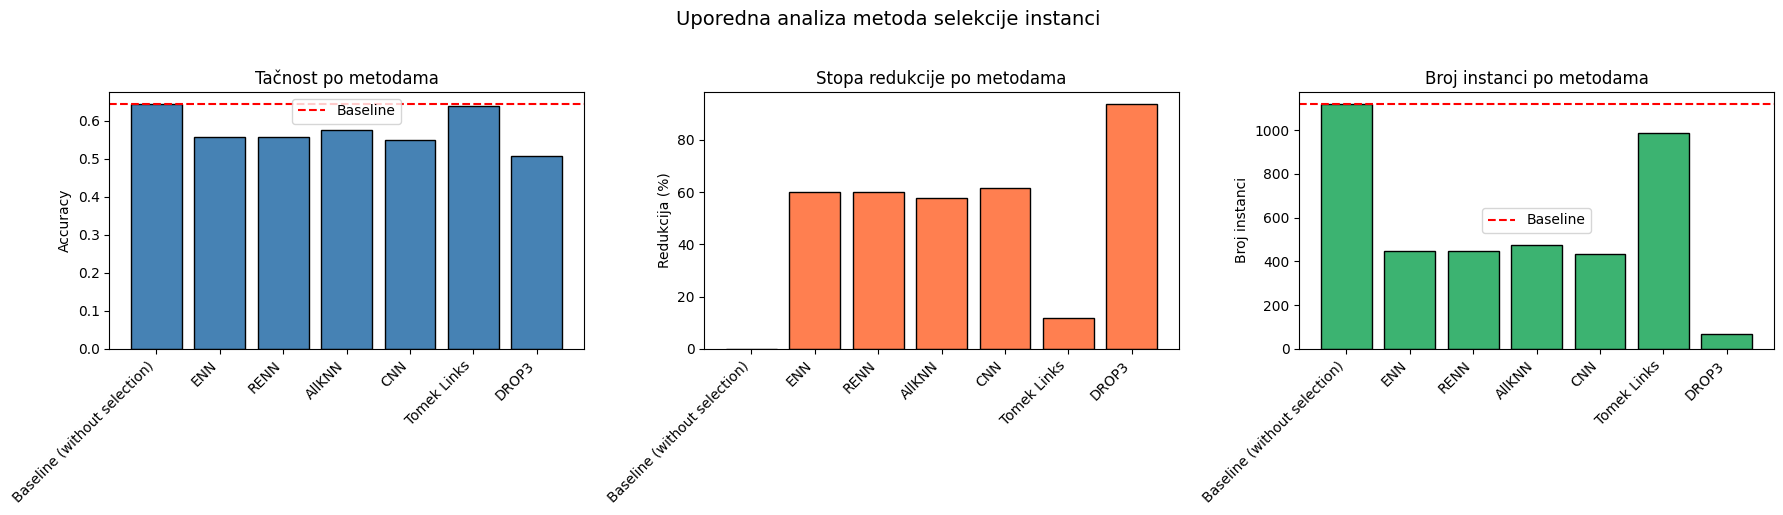

In [123]:
results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].round(4)
results_df['Predict time (s)'] = results_df['Predict time (s)'].round(4)
results_df['F1 (weighted)'] = results_df['F1 (weighted)'].round(4)

print(results_df.to_string(index=False))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = results_df['Method']
x = range(len(methods))

# Tačnost
axes[0].bar(x, results_df['Accuracy'], color='steelblue', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=45, ha='right')
axes[0].set_title('Tačnost po metodama')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(y=results_df['Accuracy'].iloc[0], color='red', linestyle='--', label='Baseline')
axes[0].legend()

# Redukcija
axes[1].bar(x, results_df['Reduction (%)'], color='coral', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=45, ha='right')
axes[1].set_title('Stopa redukcije po metodama')
axes[1].set_ylabel('Redukcija (%)')

# Broj instanci
axes[2].bar(x, results_df['Num of instances'], color='mediumseagreen', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=45, ha='right')
axes[2].set_title('Broj instanci po metodama')
axes[2].set_ylabel('Broj instanci')
axes[2].axhline(y=results_df['Num of instances'].iloc[0], color='red', linestyle='--', label='Baseline')
axes[2].legend()

plt.suptitle('Uporedna analiza metoda selekcije instanci', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Confusion matrice za sve metode
Poređenje confusion matrica omogućava da se vizuelno identifikuje kako svaka metoda selekcije instanci utiče na klasifikaciju pojedinih klasa u odnosu na baseline.

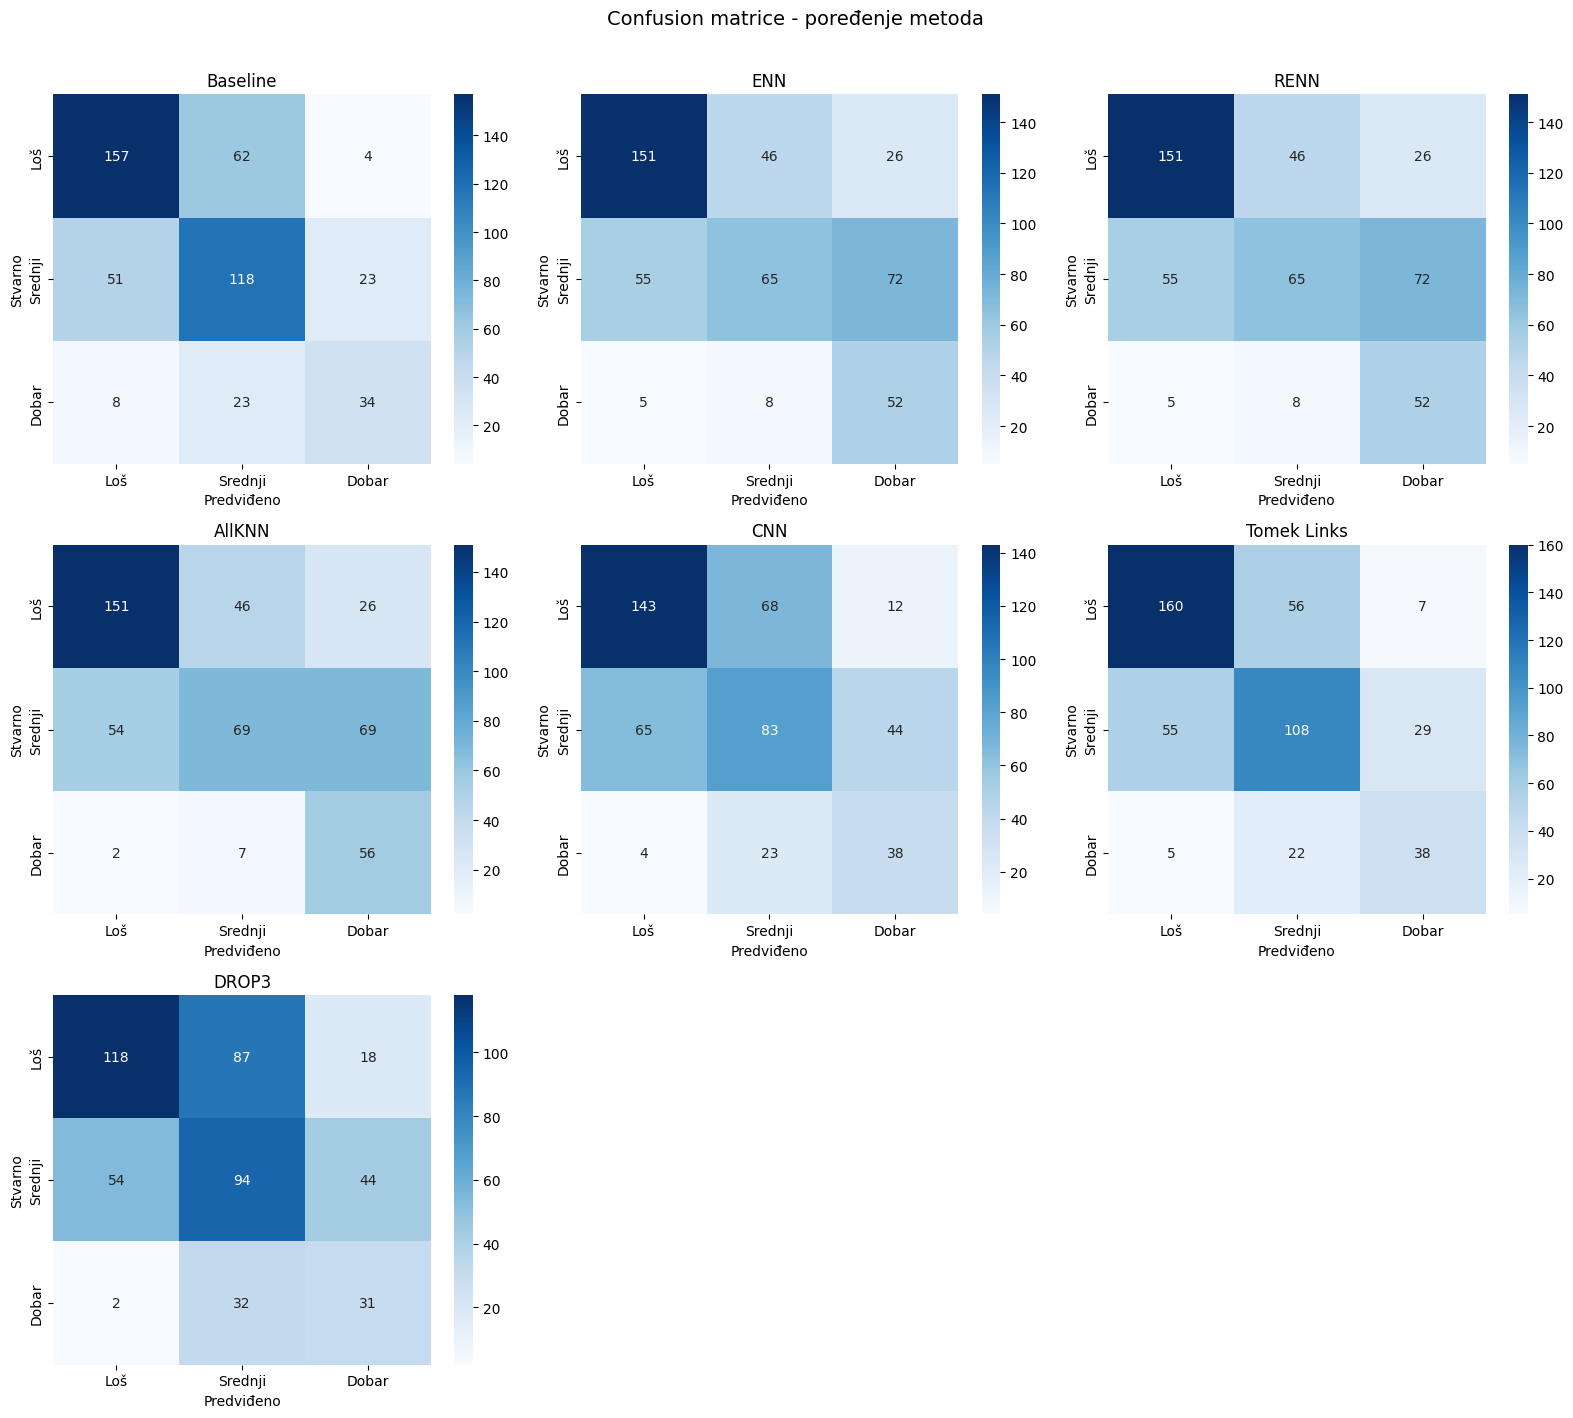

In [124]:
predictions = {
    'Baseline': y_pred,
    'ENN': y_pred_enn,
    'RENN': y_pred_renn,
    'AllKNN': y_pred_allknn,
    'CNN': y_pred_cnn,
    'Tomek Links': y_pred_tomek,
    'DROP3': y_pred_drop3
}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
labels = ['Loš', 'Srednji', 'Dobar']

for i, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    axes[i].set_title(f'{name}', fontsize=12)
    axes[i].set_xlabel('Predviđeno')
    axes[i].set_ylabel('Stvarno')

for j in range(len(predictions), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion matrice - poređenje metoda', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Distribucija klasa pre i posle selekcije
Prikaz kako svaka metoda menja broj instanci po klasama. Ovo je važno jer neke metode mogu neravnomerno uklanjati instance iz različitih klasa, što dodatno menja balans i utiče na klasifikaciju.

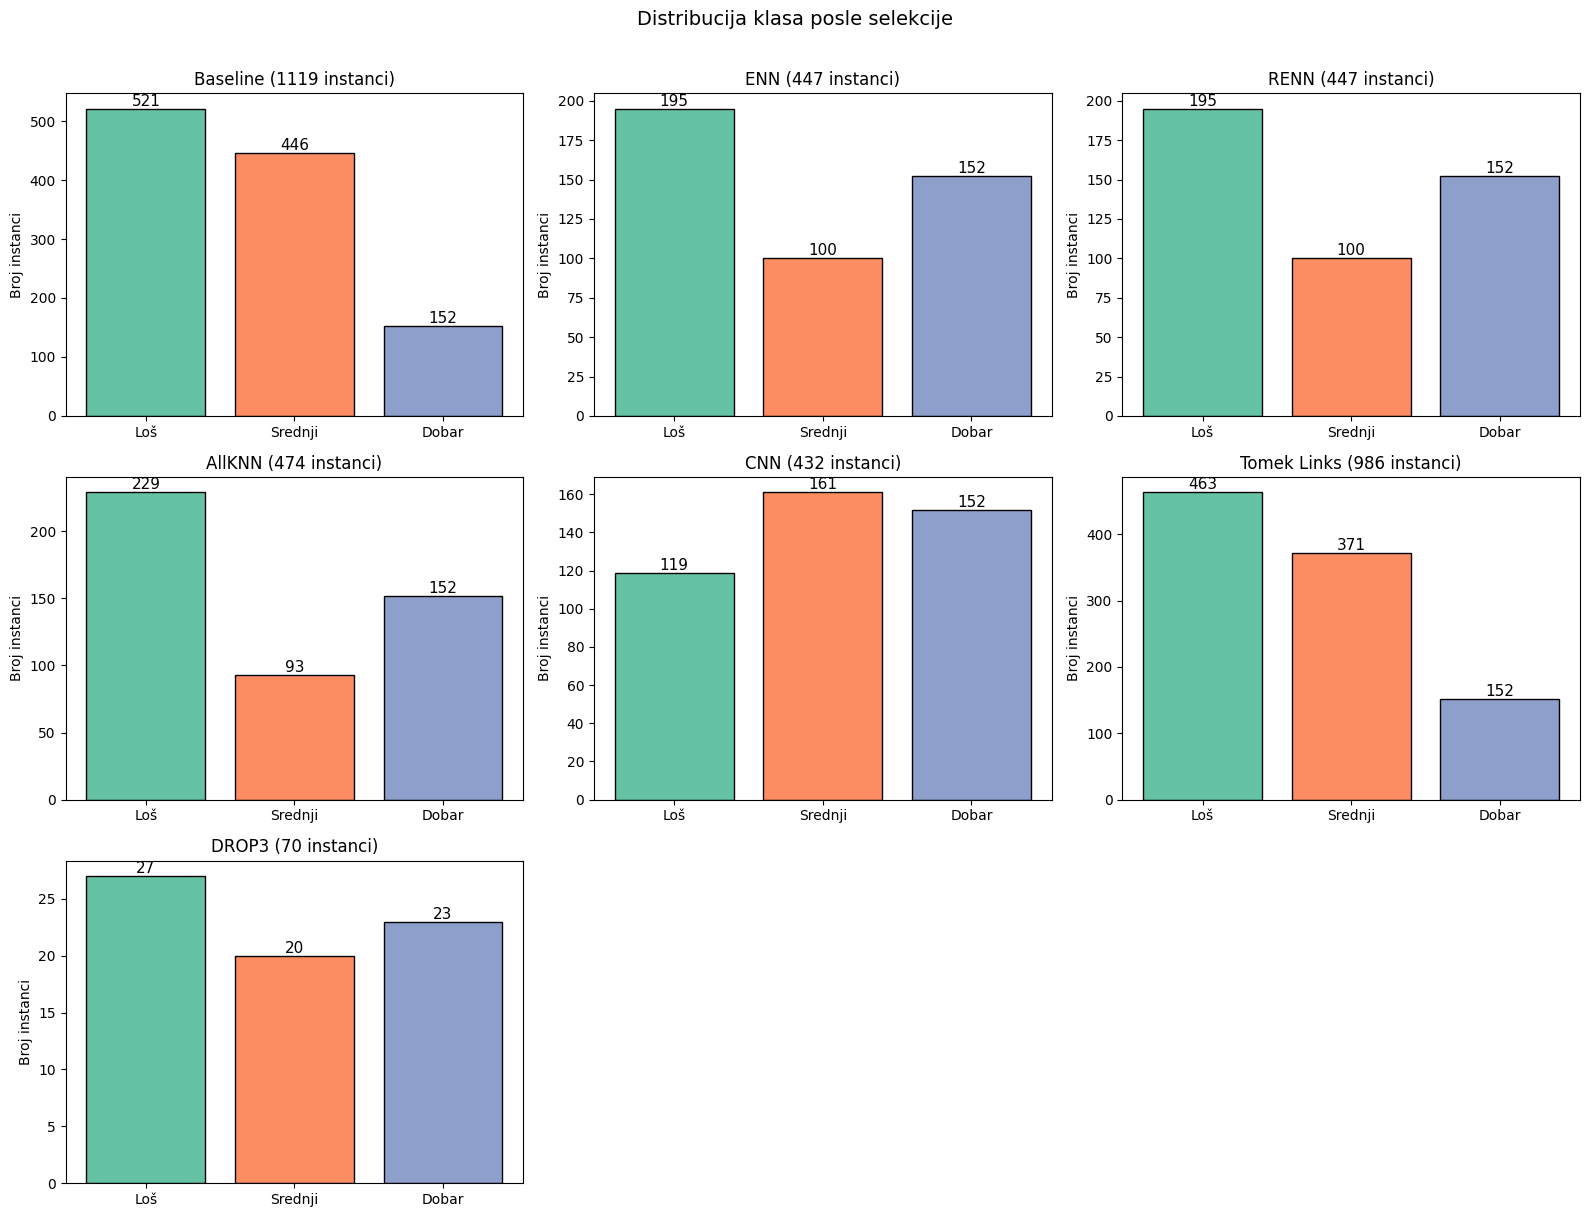

In [125]:
datasets = {
    'Baseline': y_train,
    'ENN': y_enn,
    'RENN': y_renn,
    'AllKNN': y_allknn,
    'CNN': y_cnn,
    'Tomek Links': y_tomek,
    'DROP3': y_drop3
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
labels = ['Loš', 'Srednji', 'Dobar']
colors = sns.color_palette('Set2', 3)

for i, (name, y_data) in enumerate(datasets.items()):
    counts = pd.Series(y_data).value_counts().sort_index()
    axes[i].bar(labels, counts, color=colors, edgecolor='black')
    axes[i].set_title(f'{name} ({len(y_data)} instanci)', fontsize=12)
    axes[i].set_ylabel('Broj instanci')
    for j, v in enumerate(counts):
        axes[i].annotate(f'{v}', (j, v), ha='center', va='bottom', fontsize=11)

for j in range(len(datasets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucija klasa posle selekcije', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Zaključak

Rezultati pokazuju da na ovom datasetu nijedna metoda selekcije instanci nije uspela da poboljša tačnost u odnosu na baseline k-NN (0.6438). Ovo je posledica velikog preklapanja između klasa Loš i Srednji u feature space-u. Granice između klasa nisu jasno definisane, što znači da se uklanjanjem instanci gube informacije potrebne za klasifikaciju.

Međutim, rezultati jasno demonstriraju razlike između kategorija metoda koje su obrađene u teorijskom delu:

- **Edition metode** (ENN, RENN, AllKNN) su bile preagresivne na ovom datasetu. Uklonile su 57-60% instanci i srušile tačnost za 7-9 procentnih poena, posebno pogađajući klasu Srednji. RENN je konvergirao u jednoj iteraciji što znači da ENN već u prvom prolazu detektuje sve šumne instance.

- **Kondenzacija** (CNN) je postigla najveću redukciju (61.4%) ali i najnižu tačnost (0.55), jer zadržava granične instance bez razlikovanja validnih od šumnih.

- **DROP3** kao hibridna metoda postigao je najagresivniju redukciju (93.7%) svodeći trening skup sa 1119 na 70 instanci. Tačnost je pala na 0.506, što pokazuje da čak i sa prethodnim čišćenjem šuma, decrementalna kondenzacija na datasetu sa velikim preklapanjem klasa gubi previše informacija. Na datasetima sa jasnijim granicama, DROP3 bi sačuvao tačnost znatno bolje uz istu stopu redukcije.

- **Tomek Links** se pokazao kao najstabilnija metoda. Uz najmanju redukciju (11.9%) sačuvao je tačnost praktično identičnu baseline-u (0.6375), što potvrđuje da konzervativniji pristup bolje čuva kvalitet klasifikacije kada su klase jako isprepletane.

Ključni zaključak je da izbor metode selekcije instanci zavisi od karakteristika podataka. Na datasetima sa jasno razdvojenim klasama, agresivnije metode poput CNN ili DROP3 mogu postići veliku redukciju uz očuvanu tačnost. Na datasetima sa velikim preklapanjem, poput ovog, konzervativni pristupi poput Tomek Links su bezbedniji izbor.